# Notebook 1 — Isolation Forest: Detección de Anomalías Epidemiológicas
**Proyecto:** EpiDiagnostix-Mayab  
**Componente:** Modelo ML No Supervisado  
**Objetivo:** Entrenar y evaluar un Isolation Forest sobre variables clínicas de nivel paciente para detectar anomalías epidemiológicas.  

> **Regla de oro:** Las columnas `es_brote_comunitario_real` y `es_anomalia_real` son **solo ground truth para evaluación**. Jamás se usan como features de entrada al modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
DATA_PATH  = '../consultas_clinicas.csv'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

print('Dependencias cargadas correctamente.')

Dependencias cargadas correctamente.


## 1. Carga y vista rápida del dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (4752, 21)


,id_consulta,fecha,comunidad,region,profesional,edad,sexo,peso_kg,talla_cm,presion_sistolica,...,glucosa_mg_dl,temperatura_c,frecuencia_cardiaca_bpm,categoria_sintoma,sintomas_clave,duracion_sintomas_dias,medicamento_administrado,medicamento_nombre,es_brote_comunitario_real,es_anomalia_real
0,a2d44ec1-c8d5-4d5e-a8c4-86f96c231ced,2025-11-01,Tuxtla Gutiérrez,Urbano,Enfermería,34,M,72.4,151.4,118.0,...,87.0,37.0,77.0,Respiratorio,dificultad para respirar|tos,3,Sí,Paracetamol,0,0
1,c32b0787-c25c-4952-be5d-a585b90ce983,2025-11-01,Chenalhó,Altos,Médico,88,F,70.9,171.0,110.0,...,114.0,36.2,80.0,Nutrición,palidez|debilidad|retraso en talla,1,Sí,Suplemento nutricional,0,0
2,55724ac9-c2ca-459f-b064-264436518022,2025-11-01,Chenalhó,Altos,Enfermería,4,F,18.3,81.2,159.0,...,97.0,36.2,77.0,Hipertensión,zumbido en oídos|visión borrosa,1,Sí,Captopril,0,0


In [3]:
print('Tipos de dato:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())

Tipos de dato:
id_consulta                   object
fecha                         object
comunidad                     object
region                        object
profesional                   object
edad                           int64
sexo                          object
peso_kg                      float64
talla_cm                     float64
presion_sistolica            float64
presion_diastolica           float64
glucosa_mg_dl                float64
temperatura_c                float64
frecuencia_cardiaca_bpm      float64
categoria_sintoma             object
sintomas_clave                object
duracion_sintomas_dias         int64
medicamento_administrado      object
medicamento_nombre            object
es_brote_comunitario_real      int64
es_anomalia_real               int64
dtype: object

Valores nulos por columna:
id_consulta                     0
fecha                           0
comunidad                       0
region                          0
profesional                   

In [4]:
print('Distribución del ground truth (es_anomalia_real):')
vc = df['es_anomalia_real'].value_counts()
print(vc)
print(f'\nTasa de anomalía real: {vc[1]/len(df)*100:.2f}%')

Distribución del ground truth (es_anomalia_real):
es_anomalia_real
0    4610
1     142
Name: count, dtype: int64

Tasa de anomalía real: 2.99%


## 2. EDA — Distribuciones de features numéricas

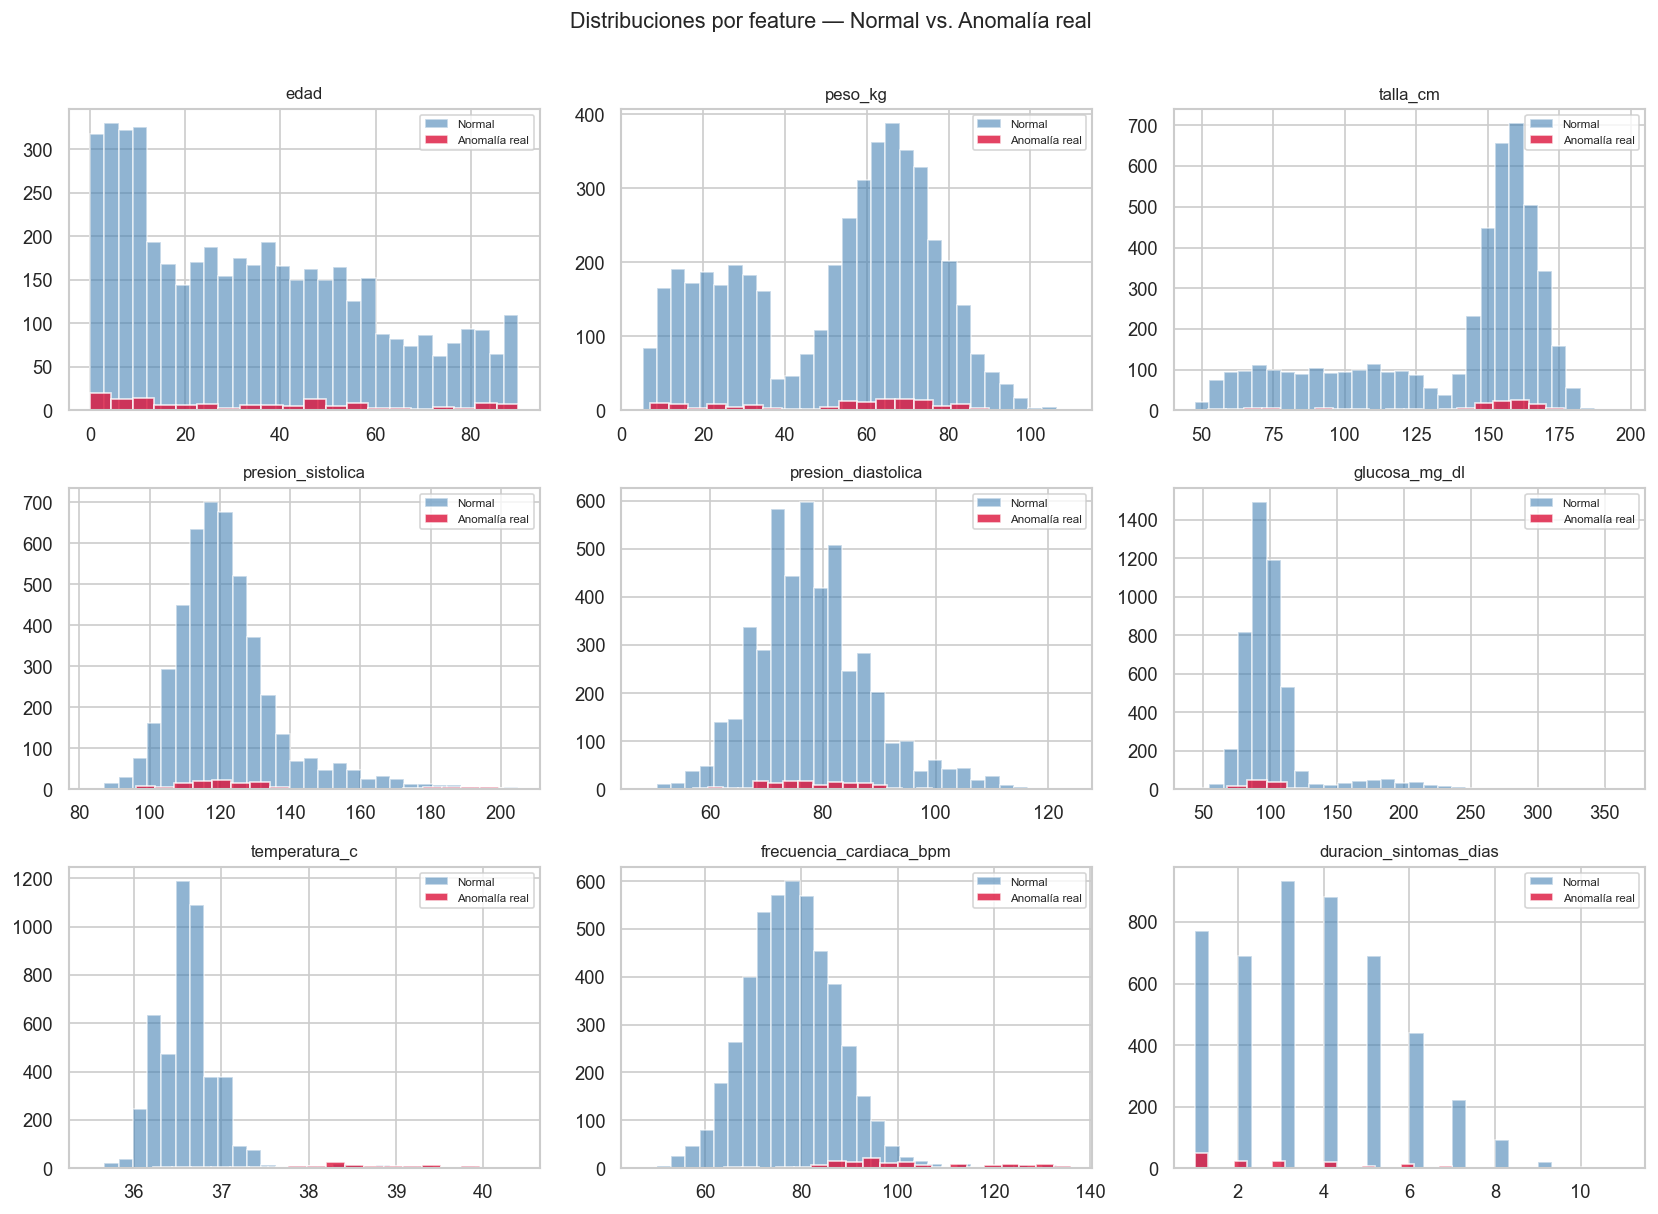

Figura guardada en models/eda_distribuciones.png


In [5]:
NUMERIC_FEATURES = [
    'edad', 'peso_kg', 'talla_cm',
    'presion_sistolica', 'presion_diastolica',
    'glucosa_mg_dl', 'temperatura_c',
    'frecuencia_cardiaca_bpm', 'duracion_sintomas_dias'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    # distribución global
    ax.hist(df[col], bins=30, color='steelblue', alpha=0.6, label='Normal')
    # superponer anomalías reales
    ax.hist(df.loc[df['es_anomalia_real']==1, col], bins=20,
            color='crimson', alpha=0.8, label='Anomalía real')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Distribuciones por feature — Normal vs. Anomalía real', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/eda_distribuciones.png', bbox_inches='tight')
plt.show()
print('Figura guardada en models/eda_distribuciones.png')

In [6]:
# Estadísticas descriptivas separadas
print('=== Casos NORMALES ===')
print(df.loc[df['es_anomalia_real']==0, NUMERIC_FEATURES].describe().round(2))
print('\n=== Casos ANÓMALOS ===')
print(df.loc[df['es_anomalia_real']==1, NUMERIC_FEATURES].describe().round(2))

=== Casos NORMALES ===
          edad  peso_kg  talla_cm  presion_sistolica  presion_diastolica  \
count  4610.00  4610.00   4610.00            4610.00             4610.00   
mean     33.76    52.40    137.28             121.45               78.07   
std      25.14    23.58     34.66              14.45               10.15   
min       0.00     5.20     47.80              83.00               48.00   
25%      10.00    30.12    112.85             113.00               71.00   
50%      31.00    59.15    153.00             119.00               77.00   
75%      52.00    70.60    161.40             127.00               83.00   
max      90.00   109.90    197.40             204.00              124.00   

       glucosa_mg_dl  temperatura_c  frecuencia_cardiaca_bpm  \
count        4610.00         4610.0                  4610.00   
mean          101.96           36.6                    77.62   
std            28.37            0.3                     9.02   
min            44.00           35.5 

In [7]:
# Outliers via IQR
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

outlier_counts = {col: count_outliers_iqr(df[col]) for col in NUMERIC_FEATURES}
print('Outliers por columna (criterio IQR 1.5x):')
for col, n in sorted(outlier_counts.items(), key=lambda x: -x[1]):
    print(f'  {col}: {n}')

Outliers por columna (criterio IQR 1.5x):
  glucosa_mg_dl: 388
  presion_sistolica: 299
  temperatura_c: 176
  presion_diastolica: 156
  frecuencia_cardiaca_bpm: 87
  duracion_sintomas_dias: 7
  edad: 0
  peso_kg: 0
  talla_cm: 0


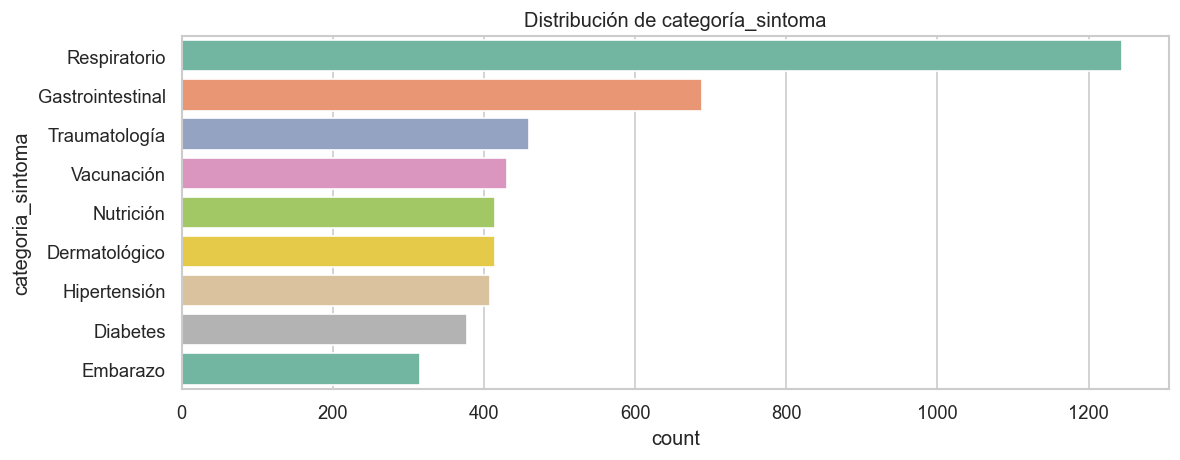

In [8]:
# Distribución de categoría_sintoma
fig, ax = plt.subplots(figsize=(10, 4))
order = df['categoria_sintoma'].value_counts().index
sns.countplot(data=df, y='categoria_sintoma', order=order, palette='Set2', ax=ax)
ax.set_title('Distribución de categoría_sintoma')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/eda_categoria_sintoma.png', bbox_inches='tight')
plt.show()

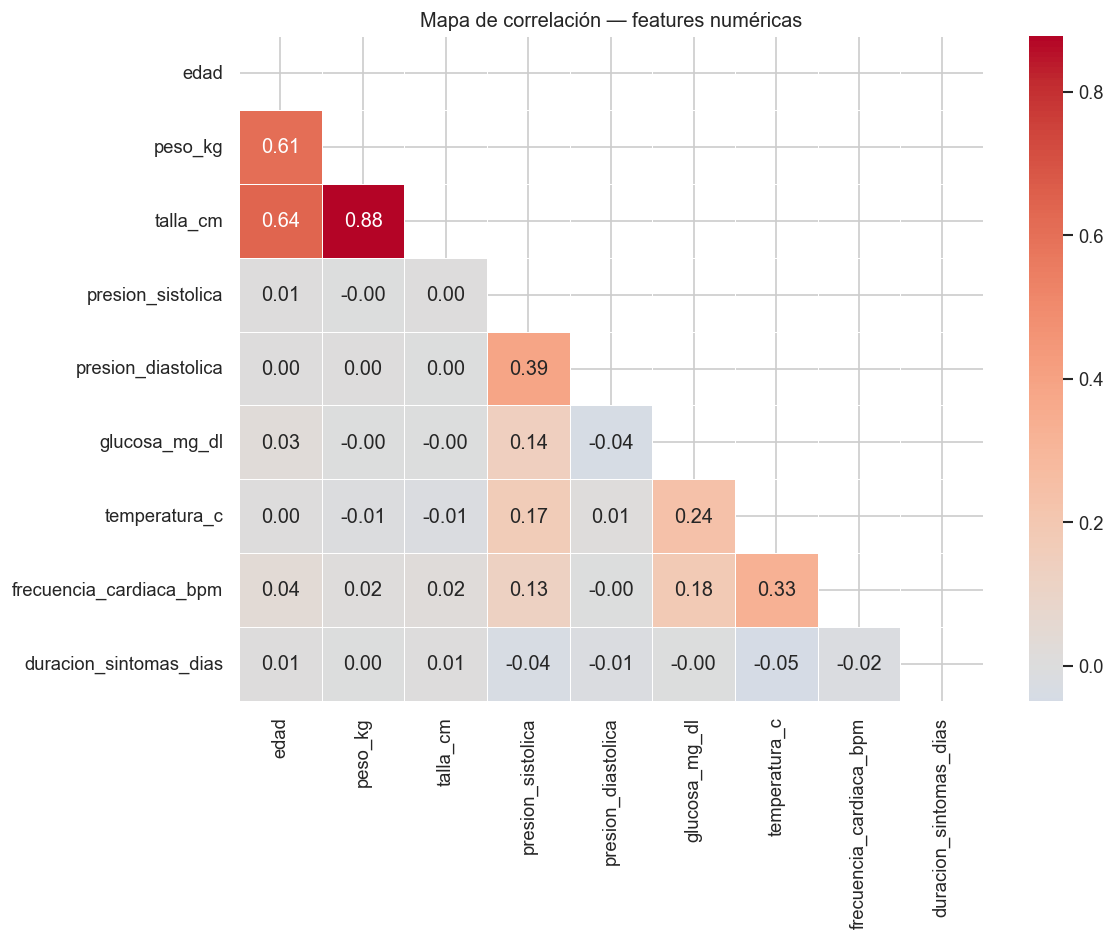

In [9]:
# Correlación entre features numéricas
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUMERIC_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Mapa de correlación — features numéricas')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/eda_correlacion.png', bbox_inches='tight')
plt.show()

## 3. Preprocesamiento

**Features seleccionadas:**
- **Numéricas (9):** edad, peso_kg, talla_cm, presion_sistolica, presion_diastolica, glucosa_mg_dl, temperatura_c, frecuencia_cardiaca_bpm, duracion_sintomas_dias  
- **Categórica codificada (1):** categoria_sintoma → LabelEncoder → StandardScaler  

**Excluidas explícitamente:** `es_brote_comunitario_real`, `es_anomalia_real` (ground truth), y todas las columnas de texto libre / identificadores.

In [10]:
# Codificar categoria_sintoma
le = LabelEncoder()
df['categoria_sintoma_enc'] = le.fit_transform(df['categoria_sintoma'])
print('Mapeo categoria_sintoma:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx} -> {cls}')

Mapeo categoria_sintoma:
  0 -> Dermatológico
  1 -> Diabetes
  2 -> Embarazo
  3 -> Gastrointestinal
  4 -> Hipertensión
  5 -> Nutrición
  6 -> Respiratorio
  7 -> Traumatología
  8 -> Vacunación


In [11]:
FEATURE_COLS = NUMERIC_FEATURES + ['categoria_sintoma_enc']
GROUND_TRUTH = ['es_anomalia_real', 'es_brote_comunitario_real']

X = df[FEATURE_COLS].copy()
y_true = df['es_anomalia_real'].values  # solo para evaluación posterior

# Verificar que no haya nulos en el set de features
assert X.isnull().sum().sum() == 0, 'Hay nulos en features — revisar'
print(f'Shape del set de features: {X.shape}')
print(f'Columnas usadas: {FEATURE_COLS}')

Shape del set de features: (4752, 10)
Columnas usadas: ['edad', 'peso_kg', 'talla_cm', 'presion_sistolica', 'presion_diastolica', 'glucosa_mg_dl', 'temperatura_c', 'frecuencia_cardiaca_bpm', 'duracion_sintomas_dias', 'categoria_sintoma_enc']


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('StandardScaler ajustado.')
print(f'Media global aprox (debería ser ~0): {X_scaled.mean():.4f}')
print(f'Std global aprox (debería ser ~1): {X_scaled.std():.4f}')

StandardScaler ajustado.
Media global aprox (debería ser ~0): 0.0000
Std global aprox (debería ser ~1): 1.0000


## 4. Entrenamiento — Barrido de `contamination`

`contamination` es la fracción esperada de anomalías. Probamos varios valores alrededor de la tasa real (~3%).

In [13]:
CONTAMINATION_VALUES = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10]

results = []
models  = {}

for c in CONTAMINATION_VALUES:
    iso = IsolationForest(
        n_estimators=200,
        contamination=c,
        max_samples='auto',
        random_state=SEED,
        n_jobs=-1
    )
    iso.fit(X_scaled)
    # IsolationForest: -1 = anomalía, 1 = normal → convertir a 0/1
    preds = (iso.predict(X_scaled) == -1).astype(int)

    prec  = precision_score(y_true, preds, zero_division=0)
    rec   = recall_score(y_true, preds, zero_division=0)
    f1    = f1_score(y_true, preds, zero_division=0)
    tp    = int(((preds == 1) & (y_true == 1)).sum())
    fp    = int(((preds == 1) & (y_true == 0)).sum())
    fn    = int(((preds == 0) & (y_true == 1)).sum())

    results.append({
        'contamination': c,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'TP': tp, 'FP': fp, 'FN': fn
    })
    models[c] = (iso, preds)
    print(f'contamination={c:.2f}  | P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}  TP={tp}  FP={fp}  FN={fn}')

results_df = pd.DataFrame(results)
print('\nListo.')

contamination=0.01  | P=0.771  R=0.261  F1=0.389  TP=37  FP=11  FN=105


contamination=0.02  | P=0.510  R=0.345  F1=0.412  TP=49  FP=47  FN=93


contamination=0.03  | P=0.406  R=0.408  F1=0.407  TP=58  FP=85  FN=84


contamination=0.05  | P=0.303  R=0.507  F1=0.379  TP=72  FP=166  FN=70


contamination=0.08  | P=0.228  R=0.613  F1=0.333  TP=87  FP=294  FN=55


contamination=0.10  | P=0.191  R=0.641  F1=0.294  TP=91  FP=385  FN=51

Listo.


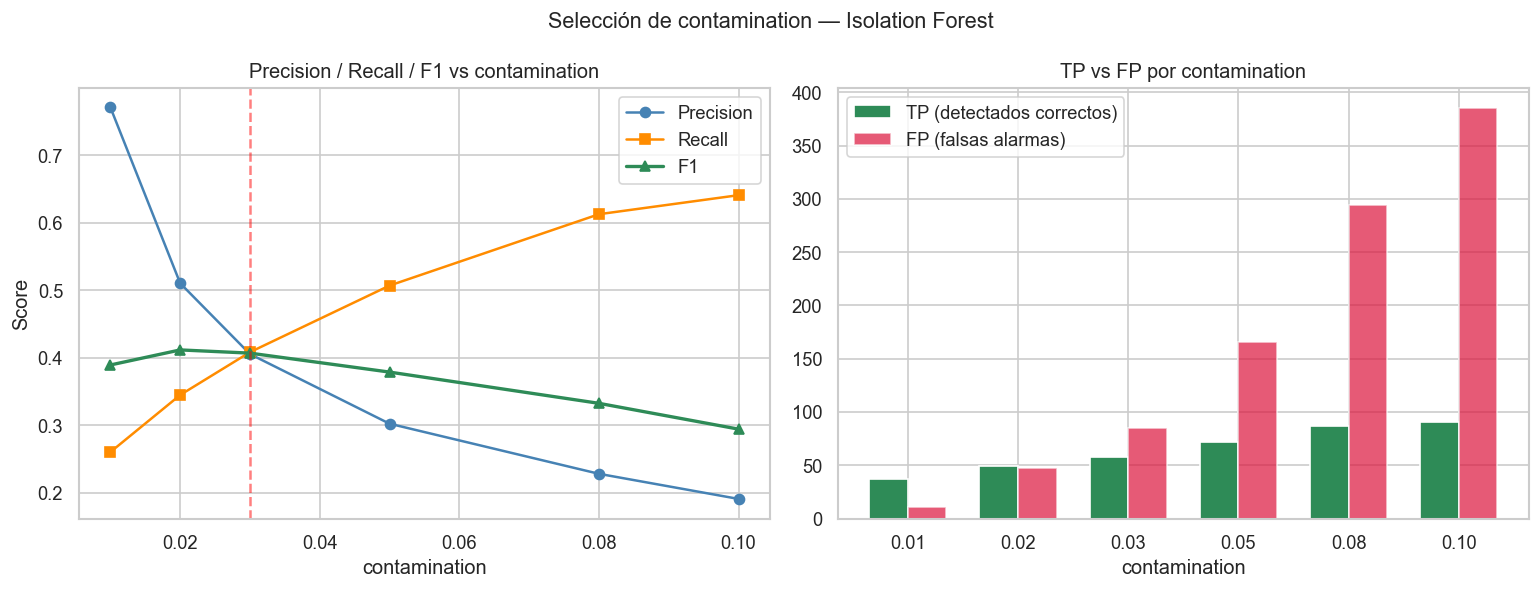

Figura guardada.


In [14]:
# Visualizar métricas vs contamination
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(results_df['contamination'], results_df['precision'], 'o-', label='Precision', color='steelblue')
ax.plot(results_df['contamination'], results_df['recall'],    's-', label='Recall',    color='darkorange')
ax.plot(results_df['contamination'], results_df['f1'],        '^-', label='F1',        color='seagreen', linewidth=2)
ax.set_xlabel('contamination')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs contamination')
ax.legend()
ax.axvline(x=0.03, color='red', linestyle='--', alpha=0.5, label='Tasa real (~3%)')

ax = axes[1]
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['TP'], width, label='TP (detectados correctos)', color='seagreen')
ax.bar(x + width/2, results_df['FP'], width, label='FP (falsas alarmas)', color='crimson', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'{c:.2f}' for c in results_df['contamination']])
ax.set_xlabel('contamination')
ax.set_title('TP vs FP por contamination')
ax.legend()

plt.suptitle('Selección de contamination — Isolation Forest', fontsize=13)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/if_contamination_sweep.png', bbox_inches='tight')
plt.show()
print('Figura guardada.')

## 5. Modelo final — Mejor configuración

In [15]:
# Elegir contamination con mejor F1
best_row = results_df.loc[results_df['f1'].idxmax()]
BEST_CONTAMINATION = best_row['contamination']
print(f'Mejor contamination: {BEST_CONTAMINATION}')
print(best_row.to_string())

best_model, best_preds = models[BEST_CONTAMINATION]

Mejor contamination: 0.02
contamination     0.020000
precision         0.510417
recall            0.345070
f1                0.411765
TP               49.000000
FP               47.000000
FN               93.000000


In [16]:
# Anomaly scores del modelo elegido (más negativo = más anómalo)
anomaly_scores = best_model.decision_function(X_scaled)

# Reporte completo
print('=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(y_true, best_preds,
                             target_names=['Normal', 'Anomalía'],
                             digits=4))

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

      Normal     0.9800    0.9898    0.9849      4610
    Anomalía     0.5104    0.3451    0.4118       142

    accuracy                         0.9705      4752
   macro avg     0.7452    0.6674    0.6983      4752
weighted avg     0.9660    0.9705    0.9678      4752



## 6. Matriz de confusión

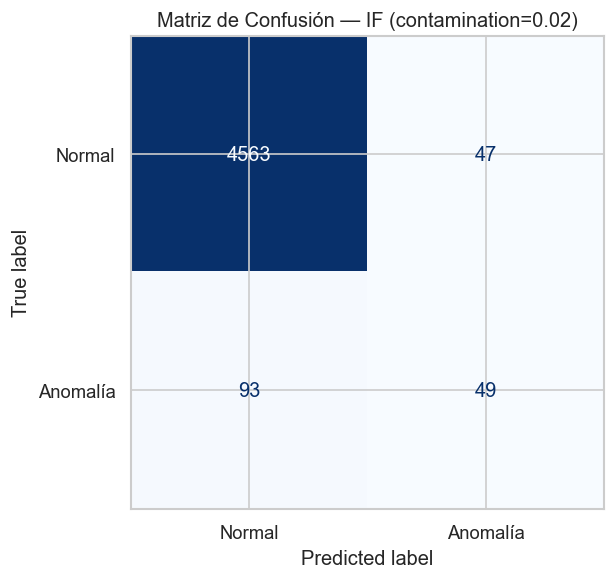

TN=4563  FP=47  FN=93  TP=49


In [17]:
cm = confusion_matrix(y_true, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalía'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — IF (contamination={BEST_CONTAMINATION})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/if_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

## 7. Visualización de Anomaly Scores

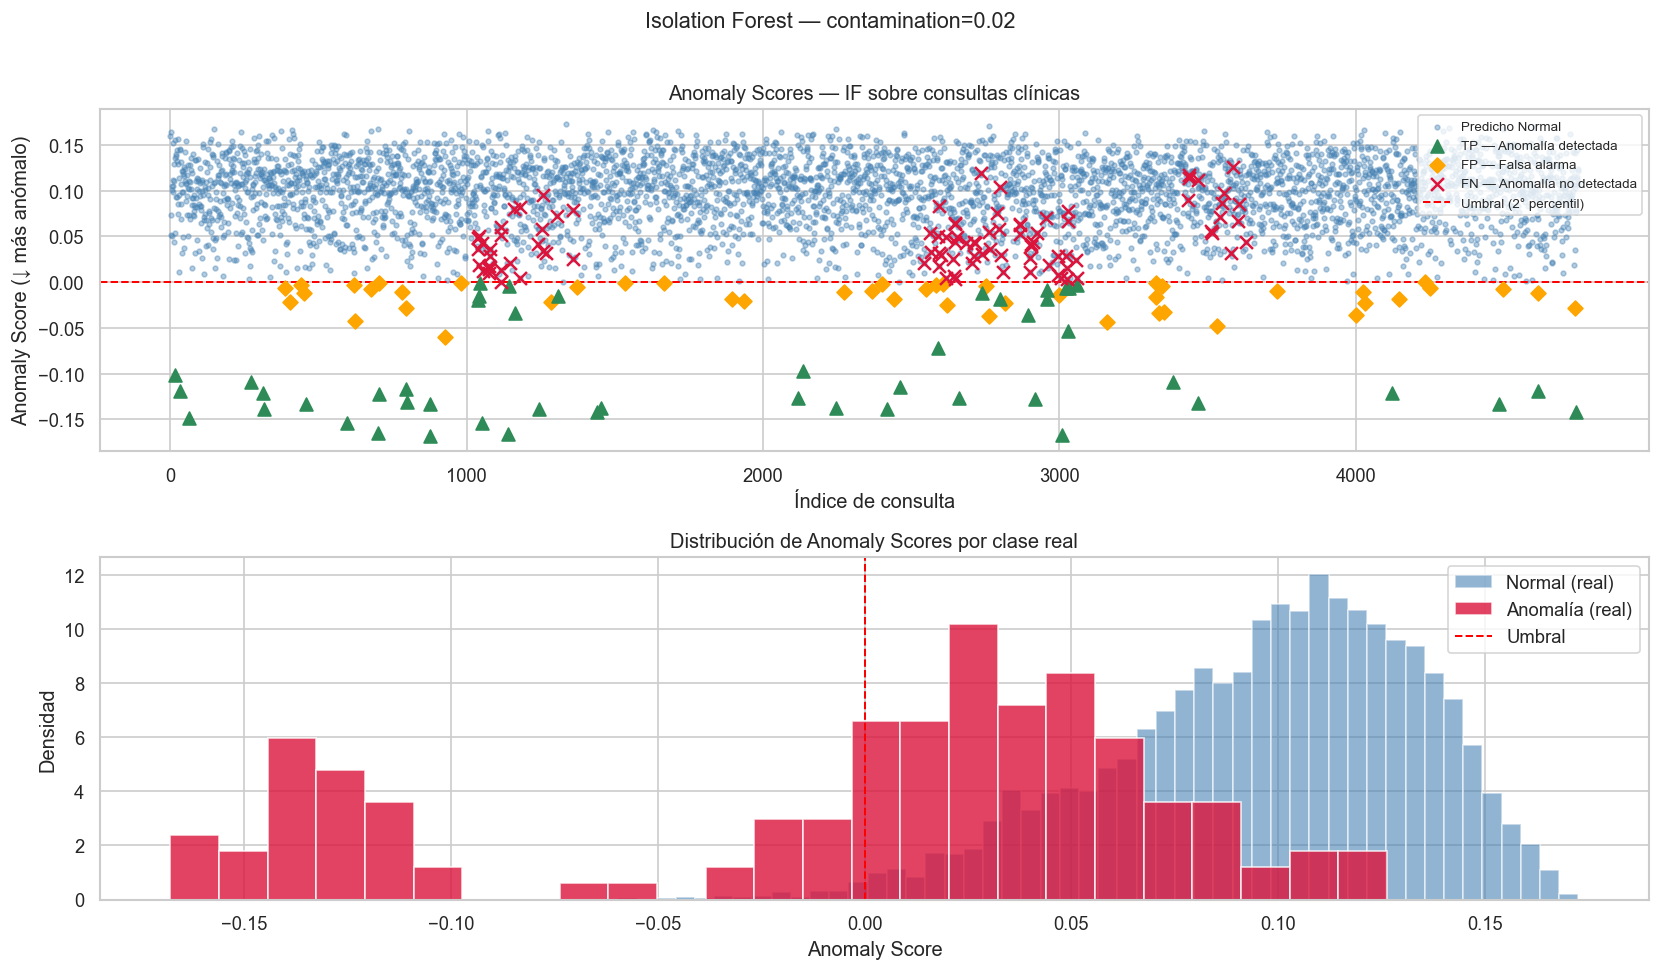

Figura guardada en models/if_anomaly_scores.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Panel 1: scores por índice de consulta ---
ax = axes[0]
idx = np.arange(len(anomaly_scores))

# Normales predichos
mask_pred_normal = (best_preds == 0)
ax.scatter(idx[mask_pred_normal], anomaly_scores[mask_pred_normal],
           c='steelblue', s=8, alpha=0.4, label='Predicho Normal')

# Anomalías predichas correctamente (TP)
mask_tp = (best_preds == 1) & (y_true == 1)
ax.scatter(idx[mask_tp], anomaly_scores[mask_tp],
           c='seagreen', s=60, marker='^', zorder=5, label='TP — Anomalía detectada')

# Falsos positivos (FP)
mask_fp = (best_preds == 1) & (y_true == 0)
ax.scatter(idx[mask_fp], anomaly_scores[mask_fp],
           c='orange', s=40, marker='D', zorder=4, label='FP — Falsa alarma')

# Falsos negativos (FN) — anomalías no detectadas
mask_fn = (best_preds == 0) & (y_true == 1)
ax.scatter(idx[mask_fn], anomaly_scores[mask_fn],
           c='crimson', s=60, marker='x', zorder=5, linewidths=1.5, label='FN — Anomalía no detectada')

# Umbral de decisión
threshold = np.percentile(anomaly_scores, BEST_CONTAMINATION * 100)
ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1.2,
           label=f'Umbral ({BEST_CONTAMINATION*100:.0f}° percentil)')

ax.set_xlabel('Índice de consulta')
ax.set_ylabel('Anomaly Score (↓ más anómalo)')
ax.set_title('Anomaly Scores — IF sobre consultas clínicas')
ax.legend(fontsize=8, loc='upper right')

# --- Panel 2: distribución de scores por clase real ---
ax2 = axes[1]
ax2.hist(anomaly_scores[y_true == 0], bins=50, color='steelblue', alpha=0.6,
         density=True, label='Normal (real)')
ax2.hist(anomaly_scores[y_true == 1], bins=25, color='crimson', alpha=0.8,
         density=True, label='Anomalía (real)')
ax2.axvline(x=threshold, color='red', linestyle='--', linewidth=1.2, label='Umbral')
ax2.set_xlabel('Anomaly Score')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de Anomaly Scores por clase real')
ax2.legend()

plt.suptitle(f'Isolation Forest — contamination={BEST_CONTAMINATION}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/if_anomaly_scores.png', bbox_inches='tight')
plt.show()
print('Figura guardada en models/if_anomaly_scores.png')

In [19]:
# Análisis adicional: ¿qué features caracterizan los TP vs FN?
tp_df = df[FEATURE_COLS].iloc[mask_tp]
fn_df = df[FEATURE_COLS].iloc[mask_fn]

print('=== Medias de features: TP (detectados) vs FN (perdidos) ===')
comparison = pd.DataFrame({
    'TP_media': tp_df[NUMERIC_FEATURES].mean(),
    'FN_media': fn_df[NUMERIC_FEATURES].mean(),
    'Global_media': df[NUMERIC_FEATURES].mean()
}).round(2)
print(comparison)
print(f'\nTotal TP: {mask_tp.sum()} | Total FN: {mask_fn.sum()}')

=== Medias de features: TP (detectados) vs FN (perdidos) ===
                         TP_media  FN_media  Global_media
edad                        34.69     35.97         33.81
peso_kg                     46.33     55.33         52.39
talla_cm                   126.36    140.59        137.23
presion_sistolica          163.27    119.97        121.86
presion_diastolica          78.96     77.32         78.06
glucosa_mg_dl              242.90     94.85        103.27
temperatura_c               39.24     38.00         36.66
frecuencia_cardiaca_bpm    117.82     93.43         78.35
duracion_sintomas_dias       3.35      2.59          3.60

Total TP: 49 | Total FN: 93


## 8. Persistencia de artefactos en `models/`

In [20]:
MODEL_PATH  = f'{MODELS_DIR}/isolation_forest.joblib'
SCALER_PATH = f'{MODELS_DIR}/scaler_if.joblib'
META_PATH   = f'{MODELS_DIR}/isolation_forest_meta.joblib'

joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler,     SCALER_PATH)

meta = {
    'feature_cols': FEATURE_COLS,
    'numeric_features': NUMERIC_FEATURES,
    'categoria_sintoma_classes': le.classes_.tolist(),
    'best_contamination': BEST_CONTAMINATION,
    'n_estimators': 200,
    'random_state': SEED,
    'train_shape': list(X_scaled.shape),
    'metrics': {
        'precision': float(best_row['precision']),
        'recall':    float(best_row['recall']),
        'f1':        float(best_row['f1']),
        'TP': int(best_row['TP']),
        'FP': int(best_row['FP']),
        'FN': int(best_row['FN'])
    }
}
joblib.dump(meta, META_PATH)

print('Artefactos guardados:')
for p in [MODEL_PATH, SCALER_PATH, META_PATH]:
    size_kb = os.path.getsize(p) / 1024
    print(f'  {p}  ({size_kb:.1f} KB)')

Artefactos guardados:
  ../models/isolation_forest.joblib  (2402.2 KB)
  ../models/scaler_if.joblib  (1.3 KB)
  ../models/isolation_forest_meta.joblib  (0.7 KB)


## 9. Resumen final de métricas

In [21]:
print('=' * 55)
print('  RESUMEN — Isolation Forest (EpiDiagnostix-Mayab)')
print('=' * 55)
print(f'  Dataset: consultas_clinicas.csv ({len(df):,} filas)')
print(f'  Features: {len(FEATURE_COLS)} columnas (9 numéricas + 1 cat.)')
print(f'  Anomalías reales: {y_true.sum()} ({y_true.mean()*100:.2f}%)')
print(f'  Mejor contamination: {BEST_CONTAMINATION}')
print()
print(f'  Precision : {best_row["precision"]:.4f}')
print(f'  Recall    : {best_row["recall"]:.4f}')
print(f'  F1-Score  : {best_row["f1"]:.4f}')
print(f'  TP        : {int(best_row["TP"])}  (anomalías detectadas correctamente)')
print(f'  FP        : {int(best_row["FP"])}  (falsas alarmas)')
print(f'  FN        : {int(best_row["FN"])}  (anomalías no detectadas)')
print()
print('  Artefactos generados:')
print('    models/isolation_forest.joblib')
print('    models/scaler_if.joblib')
print('    models/isolation_forest_meta.joblib')
print('    models/if_anomaly_scores.png')
print('    models/if_confusion_matrix.png')
print('    models/if_contamination_sweep.png')
print('=' * 55)
print()
print('Limitaciones conocidas:')
print('  - Modelo entrenado y evaluado sobre mismo set (sin split).')
print('    En producción usar datos separados de validación.')
print('  - IsolationForest no supervisado: métricas dependen de')
print('    cuán representativo sea el ground truth.')
print('  - LabelEncoder de categoria_sintoma debe aplicarse')
print('    con las mismas clases en inferencia (ver meta.joblib).')

  RESUMEN — Isolation Forest (EpiDiagnostix-Mayab)
  Dataset: consultas_clinicas.csv (4,752 filas)
  Features: 10 columnas (9 numéricas + 1 cat.)
  Anomalías reales: 142 (2.99%)
  Mejor contamination: 0.02

  Precision : 0.5104
  Recall    : 0.3451
  F1-Score  : 0.4118
  TP        : 49  (anomalías detectadas correctamente)
  FP        : 47  (falsas alarmas)
  FN        : 93  (anomalías no detectadas)

  Artefactos generados:
    models/isolation_forest.joblib
    models/scaler_if.joblib
    models/isolation_forest_meta.joblib
    models/if_anomaly_scores.png
    models/if_confusion_matrix.png
    models/if_contamination_sweep.png

Limitaciones conocidas:
  - Modelo entrenado y evaluado sobre mismo set (sin split).
    En producción usar datos separados de validación.
  - IsolationForest no supervisado: métricas dependen de
    cuán representativo sea el ground truth.
  - LabelEncoder de categoria_sintoma debe aplicarse
    con las mismas clases en inferencia (ver meta.joblib).
